# Biomarker S5 — Radiomics per-compartment + gộp với biomarker S3 + train lại classifier

Bổ sung **PyRadiomics** (texture/first-order/shape, chuẩn IBSI) lên trên các biomarker hình học
đã có ở S3 (thể tích/thickness/denuded/extrusion). Input: `cohort_manifest.csv` (S1, có `dess_path`),
`MASK_DIR` (S2, mask 8-class đã hậu xử lý), `biomarker_table.csv` (S3). Output: bảng đặc trưng gộp
`combined_features_table.csv` + model classifier mới + so sánh hiệu năng **có/không có radiomics**.

**Vùng trích đặc trưng (8 compartment):**
- 6 compartment mô mềm: `femoral_cart(2), med_tib_cart(4), lat_tib_cart(5), patellar_cart(8),
  med_meniscus(6), lat_meniscus(7)` — dùng thẳng label tương ứng.
- 2 compartment **xương dưới sụn (subchondral bone)**: không dùng toàn bộ mask xương (1,3) vì đó
  là cả thân xương (tủy + vỏ xương), không đặc hiệu cho tín hiệu OA. Thay vào đó dựng
  **lớp vỏ xương sát sụn** = `bone_mask ∩ dilate(cartilage_mask, SHELL_VOXELS)` — đúng định nghĩa
  "subchondral bone" trong y văn (texture xương dưới sụn liên hệ với KL grade, đôi khi mạnh
  hơn cả texture sụn).

**Vì sao thêm bước này có giá trị:** biomarker ở S3 (thể tích, thickness...) là feature hình học
tay-thiết-kế, Radiomics bắt được pattern texture (đồng nhất/độ nhám mô, thay đổi bè xương) mà
biomarker hình học bỏ qua — 2 loại được xem là **bổ sung cho nhau** trong y văn, không thay thế.

**Cảnh báo cần nhớ:** số đặc trưng radiomics rất lớn (~90-100/compartment × 8 = 700-800+) trong khi
N chỉ vài trăm ca → **bắt buộc** phải feature-select trên tập train (không đụng vào test) để tránh
overfit — đây là lỗi phổ biến nhất trong các paper radiomics kém tái lập.


In [1]:
!pip install -q pyradiomics-cuda SimpleITK scikit-learn pandas numpy xgboost shap
# LUU Y: goi "pyradiomics" tren PyPI KHONG con build duoc tren Python >=3.10 (Colab dang dung 3.12).
# "pyradiomics-cuda" la fork chinh thuc cua ban 3.1.0, cung tac gia, cung API "radiomics.featureextractor",
# chi dong goi lai de build duoc tren Python moi. Neu cell duoi day loi khi import, xem "Ghi chu" cuoi notebook.
import radiomics
print("pyradiomics (qua ban fork pyradiomics-cuda) - phien ban:", radiomics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 11.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.2 MB/s eta 0:00:00
pyradiomics (qua ban fork pyradiomics-cuda) - phien ban: 1.0.5.dev0+gaa3dc733b.d20251001


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0) Cấu hình

In [3]:
from pathlib import Path
import numpy as np, pandas as pd, SimpleITK as sitk
from scipy import ndimage as ndi

BIOM_DIR = Path("/content/drive/MyDrive/knee_biomarkers")
MASK_DIR = BIOM_DIR / "masks"
COHORT_CSV = BIOM_DIR / "cohort_manifest.csv"
S3_CSV     = BIOM_DIR / "biomarker_table.csv"
RAD_CSV    = BIOM_DIR / "radiomics_table.csv"          # luu incremental, resumable
COMBINED_CSV = BIOM_DIR / "combined_features_table.csv"

SHELL_VOXELS = 3   # do day lop "subchondral bone" tinh theo so voxel dilate tu be mat sun
                   # (proxy, khong phai mm chinh xac - chinh lai neu spacing anh khac biet nhieu)

# Cac soft-tissue compartment: ten -> label id trong mask 8-class
SOFT_LABELS = {
    "femoral_cart": 2, "med_tib_cart": 4, "lat_tib_cart": 5,
    "patellar_cart": 8, "med_meniscus": 6, "lat_meniscus": 7,
}

cohort = pd.read_csv(COHORT_CSV)

# >>> FIX duplicate: dedupe ngay khi load (phong khi chua chay lai ban S1/S3
# da patch, hoac cohort_manifest.csv cu con sot case_id trung).
n_before = len(cohort)
cohort = cohort.drop_duplicates(subset=["case_id"]).reset_index(drop=True)
if len(cohort) < n_before:
    print(f"CANH BAO: cohort_manifest.csv co {n_before - len(cohort)} dong trung case_id, da loai.")

mask_files = {p.stem.replace(".nii",""): p for p in MASK_DIR.glob("*.nii.gz")}
cohort = cohort[cohort["case_id"].isin(mask_files)].reset_index(drop=True)
assert not cohort["case_id"].duplicated().any(), "Van con case_id trung trong cohort!"
print("ca co du mask de trich radiomics:", len(cohort))


ca co du mask de trich radiomics: 559


## 1) Hàm dựng mask nhị phân cho từng compartment (kể cả lớp xương dưới sụn)

In [4]:
def load_arrays(case_id):
    mask_itk = sitk.ReadImage(str(mask_files[case_id]))
    mask_arr = sitk.GetArrayFromImage(mask_itk).astype(np.uint8)
    return mask_itk, mask_arr

def subchondral_shell(mask_arr, bone_lab, cart_labs):
    bone = mask_arr == bone_lab
    cart = np.isin(mask_arr, cart_labs)
    cart_dil = ndi.binary_dilation(cart, iterations=SHELL_VOXELS)
    return bone & cart_dil

def compartment_masks(mask_arr):
    comps = {name: (mask_arr == lab) for name, lab in SOFT_LABELS.items()}
    comps["femoral_subchondral_bone"] = subchondral_shell(mask_arr, bone_lab=1, cart_labs=[2])
    comps["tibial_subchondral_bone"]  = subchondral_shell(mask_arr, bone_lab=3, cart_labs=[4, 5])
    return comps

def to_sitk_mask(bool_arr, ref_itk):
    m = sitk.GetImageFromArray(bool_arr.astype(np.uint8))
    m.CopyInformation(ref_itk)
    return m


## 2) Cấu hình PyRadiomics extractor (chuẩn IBSI cơ bản)

In [5]:
from radiomics import featureextractor
import radiomics, logging
radiomics.logger.setLevel(logging.ERROR)   # tat log chi tiet, chi giu loi that su

settings = {
    "binWidth": 25,             # discretization co dinh (IBSI khuyen nghi bin-width, khong bin-count)
    "interpolator": "sitkBSpline",
    "normalize": True,          # z-score cuong do anh (DESS khong co thang chuan tuyet doi nhu CT)
    "normalizeScale": 100,
    "resampledPixelSpacing": None,  # DE None neu spacing da tuong doi dong nhat trong cohort;
                                     # neu cohort nhieu site/spacing khac biet manh, dat vd [0.5,0.5,0.5]
    "label": 1,
}

extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()
for cls in ["firstorder", "shape", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
    extractor.enableFeatureClassByName(cls)
# Wavelet/LoG: TAT mac dinh (lam no chieu dac trung x8, rat de overfit voi N vai tram ca).
# Muon bat: extractor.enableImageTypeByName("Wavelet")
print("cac feature class dang bat:", list(extractor.enabledFeatures.keys()))


cac feature class dang bat: ['firstorder', 'shape', 'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm']


## 3) Vòng lặp trích radiomics — resumable (lưu incremental, chạy lại tự bỏ qua ca đã xong)

Radiomics tốn compute hơn nhiều so với biomarker hình học ở S3 (mỗi compartment ~1-3s), nên
chạy theo `CHUNK_SIZE` và lưu ngay sau mỗi ca — mất kết nối Colab giữa chừng không mất tiến độ.

In [ ]:
CHUNK_SIZE = 80  # so ca moi lan chay cell nay

done_ids = set()
if RAD_CSV.exists():
    done_ids = set(pd.read_csv(RAD_CSV)["case_id"])
todo = cohort[~cohort["case_id"].isin(done_ids)].iloc[:CHUNK_SIZE]
print(f"da xong: {len(done_ids)} | con lai: {len(cohort) - len(done_ids)} | lam trong chunk nay: {len(todo)}")

rows = []
skipped = []
for _, row in todo.iterrows():
    case_id, dess_path = row["case_id"], row["dess_path"]
    try:
        image_itk = sitk.ReadImage(str(dess_path))
        mask_itk, mask_arr = load_arrays(case_id)
        comps = compartment_masks(mask_arr)
        feat_row = {"case_id": case_id}
        for comp_name, bool_arr in comps.items():
            if bool_arr.sum() < 50:   # qua nho, GLCM/GLRLM khong on dinh -> bo qua, de NaN
                continue
            comp_mask_itk = to_sitk_mask(bool_arr, mask_itk)
            result = extractor.execute(image_itk, comp_mask_itk)
            for k, v in result.items():
                if k.startswith("diagnostics_"):
                    continue
                feat_row[f"rad_{comp_name}_{k.replace('original_','')}"] = float(v)
        rows.append(feat_row)
    except Exception as e:
        skipped.append((case_id, str(e)))

new_df = pd.DataFrame(rows)
if RAD_CSV.exists():
    old_df = pd.read_csv(RAD_CSV)
    new_df = pd.concat([old_df, new_df], ignore_index=True)

# >>> FIX duplicate: cell nay chu dich chay lai nhieu lan (resumable). Neu
# "todo" o tren vo tinh chua case_id da co san trong RAD_CSV (vd cohort dau
# vao con trung, hoac chay lai truoc khi kip ghi file), concat se tao ra
# nhieu dong / case_id. Luon dedupe truoc khi ghi, giu ban ghi MOI NHAT.
n_before = len(new_df)
new_df = new_df.drop_duplicates(subset=["case_id"], keep="last").reset_index(drop=True)
if len(new_df) < n_before:
    print(f"CANH BAO: da loai {n_before - len(new_df)} dong trung case_id truoc khi ghi RAD_CSV.")

new_df.to_csv(RAD_CSV, index=False)
print(f"da luu {len(new_df)} ca vao {RAD_CSV}")
if skipped:
    print(f"loi/bo qua {len(skipped)} ca, vi du:", skipped[:3])
print("Neu con < tong so ca, CHAY LAI CELL NAY den khi het.")


da xong: 80 | con lai: 479 | lam trong chunk nay: 80
da luu 160 ca vao /content/drive/MyDrive/knee_biomarkers/radiomics_table.csv
Neu con < tong so ca, CHAY LAI CELL NAY den khi het.


In [6]:
from tqdm.auto import tqdm

SAVE_EVERY = 20   # ghi checkpoint moi 20 ca (an toan hon doi het moi luu, giong S3)

def _load_done_ids():
    if RAD_CSV.exists():
        return set(pd.read_csv(RAD_CSV)["case_id"])
    return set()

def _flush(buf):
    if not buf:
        return None
    new_df = pd.DataFrame(buf)
    if RAD_CSV.exists():
        old_df = pd.read_csv(RAD_CSV)
        new_df = pd.concat([old_df, new_df], ignore_index=True)
    new_df = new_df.drop_duplicates(subset=["case_id"], keep="last").reset_index(drop=True)
    new_df.to_csv(RAD_CSV, index=False)
    return len(new_df)

done_ids = _load_done_ids()
todo_all = cohort[~cohort["case_id"].isin(done_ids)]
print(f"con lai can trich radiomics: {len(todo_all)}/{len(cohort)} ca -> chay 1 mach den het")

rows_buffer, skipped = [], []
pbar = tqdm(todo_all.itertuples(index=False), total=len(todo_all), desc="Radiomics (full run)", unit="ca")

for i, row in enumerate(pbar):
    case_id, dess_path = row.case_id, row.dess_path
    try:
        image_itk = sitk.ReadImage(str(dess_path))
        mask_itk, mask_arr = load_arrays(case_id)
        comps = compartment_masks(mask_arr)
        feat_row = {"case_id": case_id}
        for comp_name, bool_arr in comps.items():
            if bool_arr.sum() < 50:   # qua nho, GLCM/GLRLM khong on dinh -> bo qua, de NaN
                continue
            comp_mask_itk = to_sitk_mask(bool_arr, mask_itk)
            result = extractor.execute(image_itk, comp_mask_itk)
            for k, v in result.items():
                if k.startswith("diagnostics_"):
                    continue
                feat_row[f"rad_{comp_name}_{k.replace('original_','')}"] = float(v)
        rows_buffer.append(feat_row)
    except Exception as e:
        skipped.append((case_id, str(e)))
        pbar.write(f"LOI o case {case_id}: {e} -> bo qua, tiep tuc")

    pbar.set_postfix(xong=len(rows_buffer), loi=len(skipped))

    if (i + 1) % SAVE_EVERY == 0:
        n_saved = _flush(rows_buffer)
        rows_buffer = []
        if n_saved:
            pbar.set_postfix_str(f"da luu {n_saved} ca vao RAD_CSV")

n_saved = _flush(rows_buffer)
total_done = len(_load_done_ids())

print(f"\nXONG TOAN BO. Tong so ca da co trong RAD_CSV: {total_done}/{len(cohort)}")
if skipped:
    print(f"loi/bo qua {len(skipped)} ca, vi du:")
    for cid, msg in skipped[:10]:
        print(f"  - {cid}: {msg}")


con lai can trich radiomics: 219/559 ca -> chay 1 mach den het


Radiomics (full run):   0%|          | 0/219 [00:00<?, ?ca/s]


XONG TOAN BO. Tong so ca da co trong RAD_CSV: 559/559


## 4) Kiểm tra tiến độ + gộp với biomarker S3

In [7]:
rad = pd.read_csv(RAD_CSV)

# >>> FIX duplicate: dedupe rad va s3 truoc khi merge, du cell 10 da dedupe
# khi ghi -- an toan kep vi day la merge nhieu-nhieu neu con sot ban trung.
rad = rad.drop_duplicates(subset=["case_id"], keep="last").reset_index(drop=True)
have = rad["case_id"].nunique()
total = len(cohort)
print(f"radiomics: {have}/{total} ca ({have/total*100:.1f}%)")

s3 = pd.read_csv(S3_CSV)
s3 = s3.drop_duplicates(subset=["case_id"], keep="last").reset_index(drop=True)
RAD_FEATURE_COLS = [c for c in rad.columns if c.startswith("rad_")]
print("so dac trung radiomics:", len(RAD_FEATURE_COLS))

combined = s3.merge(rad, on="case_id", how="inner")
assert not combined["case_id"].duplicated().any(), (
    "Van con case_id trung sau merge s3 x rad -> kiem tra lai bien dau vao!"
)
combined.to_csv(COMBINED_CSV, index=False)
print("da luu:", COMBINED_CSV, "| so ca:", len(combined), "| so cot:", combined.shape[1])


radiomics: 559/559 ca (100.0%)
so dac trung radiomics: 856
da luu: /content/drive/MyDrive/knee_biomarkers/combined_features_table.csv | so ca: 559 | so cot: 880


## 5) Feature reduction — CHỈ trên tập train (tránh rò rỉ)

Bước bắt buộc: số đặc trưng radiomics >> N. Quy trình 2 bước: (1) loại đặc trưng tương quan cao
(|r|>0.9, giữ 1 trong 2), (2) LASSO (L1 logistic) chọn tập con thật sự có đóng góp.

In [8]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

S3_FEATURE_COLS = [c for c in s3.columns if c.startswith(("vol_", "thickness_", "denuded_", "extrusion_"))]
ALL_FEATURE_COLS = S3_FEATURE_COLS + RAD_FEATURE_COLS

df = combined.dropna(subset=ALL_FEATURE_COLS, how="all").copy()
for c in ALL_FEATURE_COLS:
    df[c] = df[c].fillna(df[c].median())

X = df[ALL_FEATURE_COLS]; y = df["KL"].astype(int); groups = df["subject"].astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# (1) loc tuong quan cao - chi fit tren train
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.9).any()]
kept_cols = [c for c in ALL_FEATURE_COLS if c not in to_drop]
print(f"loai {len(to_drop)} dac trung tuong quan cao, con lai {len(kept_cols)}")

# (2) LASSO chon feature - fit scaler + LASSO CHI tren train
scaler = StandardScaler().fit(X_train[kept_cols])
Xtr_s = scaler.transform(X_train[kept_cols])
Xte_s = scaler.transform(X_test[kept_cols])

le = LabelEncoder().fit(y)

# >>> FIX (loi goc lam vo ca cell 16 va cell 18): C=0.05 qua manh so voi
# N_train nho (~70 ca) va 267 dac trung con lai sau buoc loc tuong quan ->
# LASSO zero-out TOAN BO he so, selected_cols rong -> XGBClassifier.fit() o
# cell sau nhan X co 0 cot va crash (IndexError: list index out of range).
# Thay vi 1 gia tri C co dinh, do C tang dan cho den khi co it nhat
# MIN_FEATURES dac trung duoc chon. Van uu tien C nho nhat co the (regularize
# manh nhat, dung trong y van cho bai toan feature >> N) va chi noi long khi
# that su can, thay vi mot gia tri C "doan mo" co the vo tinh chon duoc 0.
MIN_FEATURES = 10
C_CANDIDATES = [0.05, 0.08, 0.12, 0.2, 0.3, 0.5, 0.8, 1.0]

selected_cols, lasso = [], None
for C in C_CANDIDATES:
    cand = LogisticRegression(penalty="l1", solver="saga",
                               C=C, max_iter=5000, random_state=42)
    cand.fit(Xtr_s, le.transform(y_train))
    coef_nonzero = np.abs(cand.coef_).sum(axis=0) > 1e-6
    cols = [c for c, keep in zip(kept_cols, coef_nonzero) if keep]
    if len(cols) >= MIN_FEATURES:
        lasso, selected_cols = cand, cols
        print(f"C={C}: LASSO chon {len(cols)}/{len(kept_cols)} dac trung -> dung C nay")
        break
    print(f"C={C}: LASSO chi chon {len(cols)}/{len(kept_cols)} dac trung (< {MIN_FEATURES}), thu C lon hon...")

if not selected_cols:
    # Toan bo C_CANDIDATES deu khong du -> fallback: giu top-K dac trung theo
    # tuong quan don bien voi KL (khong dung LASSO nua), de pipeline khong vo
    # o cell sau. In canh bao ro vi day la fallback, khong phai lua chon ly tuong.
    print("CANH BAO: khong C nao trong C_CANDIDATES cho du dac trung -> fallback top-K theo tuong quan don bien voi KL.")
    univ_corr = X_train[kept_cols].apply(lambda col: abs(np.corrcoef(col, y_train)[0, 1]))
    selected_cols = univ_corr.sort_values(ascending=False).head(MIN_FEATURES).index.tolist()

print(f"\nSo dac trung cuoi cung duoc chon: {len(selected_cols)}")
print("vi du dac trung duoc chon:", selected_cols[:15])


loai 589 dac trung tuong quan cao, con lai 282
C=0.05: LASSO chon 40/282 dac trung -> dung C nay

So dac trung cuoi cung duoc chon: 40
vi du dac trung duoc chon: ['thickness_femoral_mm', 'extrusion_med_meniscus', 'rad_femoral_cart_shape_Flatness', 'rad_femoral_cart_shape_Sphericity', 'rad_femoral_cart_firstorder_Kurtosis', 'rad_femoral_cart_firstorder_Skewness', 'rad_femoral_cart_glcm_ClusterShade', 'rad_femoral_cart_glcm_Idmn', 'rad_femoral_cart_glrlm_LongRunLowGrayLevelEmphasis', 'rad_femoral_cart_gldm_LargeDependenceHighGrayLevelEmphasis', 'rad_femoral_cart_ngtdm_Contrast', 'rad_med_tib_cart_shape_MajorAxisLength', 'rad_med_tib_cart_glszm_ZoneEntropy', 'rad_med_tib_cart_ngtdm_Strength', 'rad_lat_tib_cart_shape_Flatness']


## 6) Train lại classifier — so sánh S3-only vs S3+Radiomics (đã feature-select)

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, cohen_kappa_score

def train_eval(feature_cols, name):
    Xtr, Xte = X_train[feature_cols], X_test[feature_cols]
    clf = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         objective="multi:softprob", num_class=len(le.classes_),
                         eval_metric="mlogloss", random_state=42)
    clf.fit(Xtr, le.transform(y_train))
    pred = le.inverse_transform(clf.predict(Xte))
    kappa = cohen_kappa_score(y_test, pred, weights="quadratic")
    print(f"--- {name} ({len(feature_cols)} dac trung) ---")
    print(classification_report(y_test, pred, zero_division=0))
    print("Quadratic-weighted kappa:", round(kappa, 3))
    return clf, kappa, pred

clf_s3only, kappa_s3only, _   = train_eval(S3_FEATURE_COLS, "S3 only (hinh hoc)")
clf_combined, kappa_comb, pred_comb = train_eval(selected_cols, "S3 + Radiomics (da feature-select)")

print("\n=== SO SANH ===")
print(f"S3 only:          kappa = {kappa_s3only:.3f}")
print(f"S3 + Radiomics:   kappa = {kappa_comb:.3f}")
print("(kappa cao hon = tot hon; neu S3+Radiomics KHONG cao hon ro ret, radiomics chua chac dang cong them do phuc tap)")


--- S3 only (hinh hoc) (15 dac trung) ---
              precision    recall  f1-score   support

           0       0.44      0.48      0.46        23
           1       0.30      0.27      0.29        11
           2       0.50      0.52      0.51        27
           3       0.62      0.76      0.68        37
           4       0.43      0.18      0.25        17

    accuracy                           0.51       115
   macro avg       0.46      0.44      0.44       115
weighted avg       0.50      0.51      0.50       115

Quadratic-weighted kappa: 0.634
--- S3 + Radiomics (da feature-select) (40 dac trung) ---
              precision    recall  f1-score   support

           0       0.56      0.65      0.60        23
           1       0.22      0.18      0.20        11
           2       0.57      0.48      0.52        27
           3       0.51      0.59      0.55        37
           4       0.46      0.35      0.40        17

    accuracy                           0.50       115

## 6b) [MỚI] Sensitivity analysis — kết quả có đổi khi chỉ dùng case tin cậy cao không?

Tương tự S4: so `S3+Radiomics` train/test trên toàn bộ `df` vs chỉ trên case có ít nhất 1 phần
GT thật (`gt_real_imorphics` + `partial_gt_oaizib_ai_meniscus_patella`). Dùng `selected_cols`
(đã qua feature-selection ở mục 5) để so sánh công bằng với model `clf_combined` chính.

In [10]:
from sklearn.metrics import accuracy_score

HIGH_CONF = {"gt_real_imorphics", "partial_gt_oaizib_ai_meniscus_patella"}
assert "source_dataset" in df.columns, "Thieu cot source_dataset -> chay lai ban S1/S2/S3 da patch."

def eval_subset_s5(mask, label, feature_cols):
    sub = df[mask].copy()
    if sub["subject"].nunique() < 10 or sub["KL"].nunique() < 2:
        print(f"[{label}] qua it du lieu/nhan ({len(sub)} ca) -> bo qua")
        return None
    Xs, ys, gs = sub[feature_cols], sub["KL"].astype(int), sub["subject"].astype(str)
    gss_s = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_i, te_i = next(gss_s.split(Xs, ys, gs))
    y_enc = le.transform(ys)   # le da fit tren toan bo y goc o muc 5
    clf_s = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8,
                           objective="multi:softprob", num_class=len(le.classes_),
                           eval_metric="mlogloss", random_state=42)
    clf_s.fit(Xs.iloc[tr_i], y_enc[tr_i])
    pred_s = clf_s.predict(Xs.iloc[te_i])
    acc = accuracy_score(y_enc[te_i], pred_s)
    kappa = cohen_kappa_score(y_enc[te_i], pred_s, weights="quadratic")
    print(f"[{label}] n={len(sub)} | test_n={len(te_i)} | acc={acc:.3f} | qw_kappa={kappa:.3f}")
    return dict(label=label, n=len(sub), accuracy=acc, qw_kappa=kappa)

print("=== So sanh (S3+Radiomics): toan bo cohort vs chi case tin cay cao ===")
res_full = eval_subset_s5(pd.Series(True, index=df.index), "toan_bo_cohort", selected_cols)
res_high = eval_subset_s5(df["source_dataset"].isin(HIGH_CONF), "chi_tin_cay_cao", selected_cols)

if res_full and res_high:
    diff_kappa = abs(res_full["qw_kappa"] - res_high["qw_kappa"])
    print(f"\nchenh lech qw_kappa: {diff_kappa:.3f}")
    if diff_kappa > 0.1:
        print("CANH BAO: chenh lech kappa > 0.1 -> nhan AI/pseudo co the dang anh huong ket qua.")
    else:
        print("Chenh lech nho -> ket qua kha on dinh du co dung them case AI-bu nhan.")


=== So sanh (S3+Radiomics): toan bo cohort vs chi case tin cay cao ===
[toan_bo_cohort] n=559 | test_n=115 | acc=0.504 | qw_kappa=0.694
[chi_tin_cay_cao] n=538 | test_n=107 | acc=0.579 | qw_kappa=0.838

chenh lech qw_kappa: 0.144
CANH BAO: chenh lech kappa > 0.1 -> nhan AI/pseudo co the dang anh huong ket qua.


## 7) SHAP trên model gộp — biomarker/texture nào đóng góp nhiều nhất

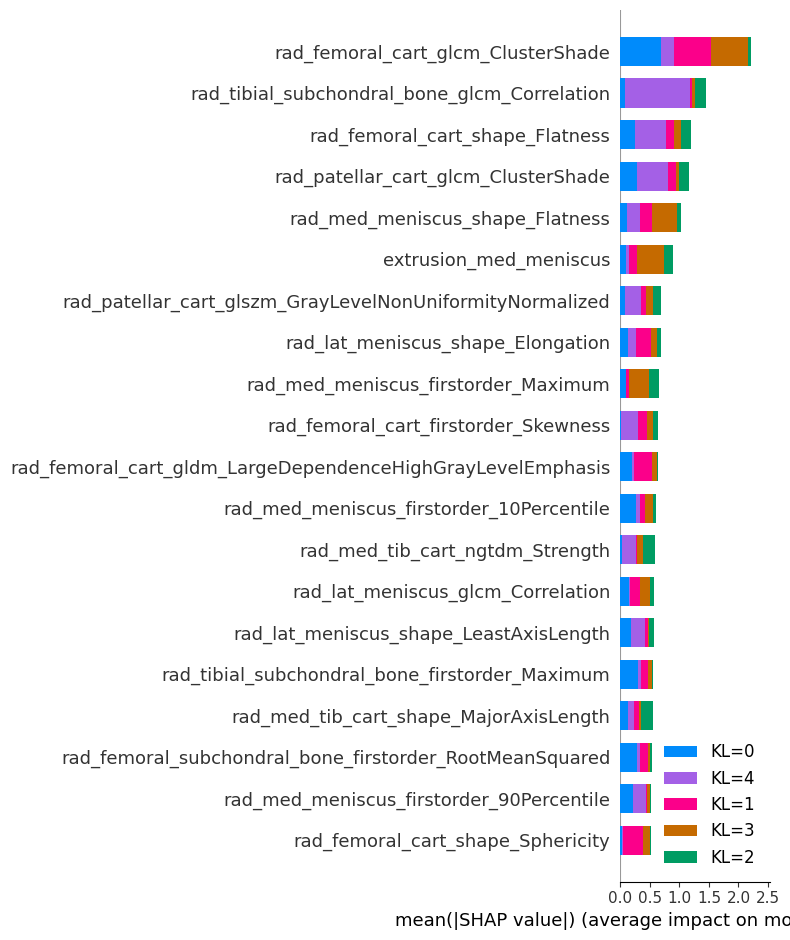

In [11]:
import shap, matplotlib.pyplot as plt
import matplotlib.ticker as mticker

explainer = shap.TreeExplainer(clf_combined, feature_perturbation="tree_path_dependent")
sv = explainer(X_test[selected_cols])

plt.figure(figsize=(16, 9))
shap.summary_plot(sv, X_test[selected_cols], plot_type="bar", show=False, max_display=20,
                   class_names=[f"KL={c}" for c in le.classes_])

ax = plt.gca()
max_edge = max((p.get_x() + p.get_width() for p in ax.patches), default=1.0)
ax.set_xlim(0, max_edge * 1.15)

# >>> FIX v4: mac dinh truc x chi hien 2 tick "0" va "1" (matplotlib tu chon
# qua it tick vi khoang du lieu hep). Ep truc chia nho ra nhieu muc trung
# gian (vd 0, 0.2, 0.4, ...) bang MaxNLocator de nhin ro ti le cua tung bar
# thay vi chi thay 2 dau mut.
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

plt.tight_layout()
plt.savefig("/content/shap_summary_s5.png", dpi=150)
plt.show()


## 8) Lưu kết quả

In [12]:
import joblib, json, shutil

MODEL_DIR = BIOM_DIR / "model_kl_classifier"
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(clf_combined, MODEL_DIR / "xgb_kl_classifier_s3_radiomics.joblib")
with open(MODEL_DIR / "selected_radiomics_features.json", "w") as f:
    json.dump(selected_cols, f, indent=2, ensure_ascii=False)
pd.DataFrame({"case_id": df.iloc[test_idx]["case_id"], "KL_true": y_test, "KL_pred": pred_comb}) \
    .to_csv(MODEL_DIR / "test_predictions_s5.csv", index=False)
shutil.copy("/content/shap_summary_s5.png", MODEL_DIR / "shap_summary_s5.png")
pd.DataFrame([{"model": "S3_only", "kappa": kappa_s3only},
              {"model": "S3_plus_radiomics", "kappa": kappa_comb}]) \
    .to_csv(MODEL_DIR / "s5_comparison.csv", index=False)
print("da luu vao:", MODEL_DIR)


da luu vao: /content/drive/MyDrive/knee_biomarkers/model_kl_classifier


## Ghi chú
- `combined_features_table.csv` là bảng đầy đủ (S3 + toàn bộ radiomics thô, chưa lọc) — giữ lại
  để thử lại feature selection khác về sau mà không cần trích lại radiomics (bước tốn thời gian nhất).
- Lớp "subchondral bone" ở đây là **proxy hình học** (dilate `SHELL_VOXELS` voxel từ sụn vào xương),
  không phải phép đo mm chính xác — nếu cần chuẩn hơn, đổi sang dilate theo mm thực (nhân với spacing)
  thay vì số voxel cố định.
- `resampledPixelSpacing=None` hiện tại giả định spacing trong cohort không lệch nhau quá nhiều.
  Nếu cohort trộn nhiều site OAI với spacing khác biệt rõ, nên bật resample cố định (vd `[0.5,0.5,0.5]`)
  để đặc trưng texture không bị nhiễu bởi độ phân giải khác nhau giữa các ca — đây chính là điểm
  IBSI nhấn mạnh nhiều nhất.
- Nếu `kappa` của "S3 + Radiomics" không nhỉnh hơn rõ so với "S3 only", đừng vội kết luận Radiomics
  vô dụng — thử tăng cỡ mẫu, hoặc thử enable thêm `Wavelet`/`LoG` filter (cell mục 2) trước khi
  kết luận, vì tín hiệu texture nhiều khi cần N lớn hơn hình học mới lộ rõ.

**Nếu `pip install pyradiomics-cuda` cũng lỗi (fork ngừng cập nhật/đổi tên...):** thư viện thay thế
đáng cân nhắc là **PySERA** (`pip install pysera`, thuần Python, đang được bảo trì tích cực, chuẩn
IBSI đầy đủ hơn cả pyradiomics gốc). Lưu ý API khác hẳn (`pysera.process_batch(image_input=...,
mask_input=..., output_path=..., categories=..., dimensions=...)`, nhận mask nhiều-nhãn qua
`roi_selection_mode="per_region"`) — cần viết lại phần "2) Cấu hình extractor" và vòng lặp trích
ở mục 3 cho khớp, mình có thể viết lại đoạn đó nếu bạn cần chuyển hướng này.


In [ ]:
from google.colab import runtime
runtime.unassign()